# 모델 성능 비교

`models` 폴더에 저장된 `*_best.pt` 모델들을 같은 test 데이터셋으로 평가합니다.

비교 항목은 다음과 같습니다.

- Test Accuracy
- Test Macro F1
- Test Loss
- 추론 시간(ms/image)
- 모델 파일 크기(MB)
- 파라미터 수
- Classification Report
- Confusion Matrix

## 1. 라이브러리 불러오기

In [18]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## 2. 기본 설정

- `dataset/test` 폴더를 기준으로 모든 모델을 동일하게 평가합니다.
- GPU가 있으면 CUDA를 사용하고, 없으면 CPU로 실행합니다.

In [19]:
data_path = Path("dataset")
model_dir = Path("models")
result_path = Path("model_compare_results.csv")

batch_size = 16
num_workers = 0
seed = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 3. 비교할 모델 파일 확인

In [20]:
model_paths = sorted(model_dir.glob("*_best.pt"))

if not model_paths:
    raise FileNotFoundError(f"{model_dir} 폴더에서 *_best.pt 모델 파일을 찾지 못했습니다.")

pd.DataFrame({
    "model_file": [path.name for path in model_paths],
    "size_mb": [path.stat().st_size / (1024 ** 2) for path in model_paths],
})

,model_file,size_mb
0,efficientnet_b0_best.pt,15.591741
1,efficientnet_b2_best.pt,29.832368
2,efficientnet_b3_best.pt,41.357657
3,efficientnet_v2_s_best.pt,77.855117
4,mobilenet_v3_large_best.pt,16.245406
5,resnet18_best.pt,42.717540
6,resnet34_best.pt,81.336070
7,resnet50_best.pt,90.004977


## 4. Test 데이터셋 준비

학습 때와 같은 ImageNet normalize 값을 사용합니다. 모델마다 체크포인트에 저장된 `image_size`가 있으면 그 값을 사용하고, 없으면 224를 사용합니다.

In [21]:
def make_eval_transform(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def make_test_loader(image_size: int):
    test_data = datasets.ImageFolder(data_path / "test", transform=make_eval_transform(image_size))
    test_loader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )
    return test_data, test_loader

sample_test_data, _ = make_test_loader(224)
print("test classes:", sample_test_data.classes)
print("test count:", len(sample_test_data))

pd.Series(sample_test_data.targets).value_counts().sort_index().rename(index=dict(enumerate(sample_test_data.classes))).to_frame("count")

test classes: ['Attentive', 'Drowsy', 'LookingAway']
test count: 167


,count
Attentive,53
Drowsy,58
LookingAway,56


## 5. 모델 구조 만들기

저장된 체크포인트 이름(`resnet18`, `efficientnet_b0` 등)에 맞춰 같은 구조를 다시 만든 뒤, 마지막 분류 레이어만 클래스 수에 맞게 교체합니다.

In [22]:
def change_fc(model, class_count: int):
    model.fc = nn.Linear(model.fc.in_features, class_count)
    return model


def change_classifier(model, class_count: int):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, class_count)
    return model


model_list = {
    "resnet18": [models.resnet18, change_fc],
    "resnet34": [models.resnet34, change_fc],
    "resnet50": [models.resnet50, change_fc],
    "mobilenet_v3_large": [models.mobilenet_v3_large, change_classifier],
    "efficientnet_b0": [models.efficientnet_b0, change_classifier],
    "efficientnet_b2": [models.efficientnet_b2, change_classifier],
    "efficientnet_b3": [models.efficientnet_b3, change_classifier],
    "efficientnet_v2_s": [models.efficientnet_v2_s, change_classifier],
}


def infer_model_name(path: Path, checkpoint: dict):
    if "model_name" in checkpoint:
        return checkpoint["model_name"]
    return path.stem.removesuffix("_best")


def load_checkpoint(path: Path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def get_class_names(checkpoint: dict):
    if "class_names" in checkpoint:
        return list(checkpoint["class_names"])
    if "class_to_idx" in checkpoint:
        return [name for name, _ in sorted(checkpoint["class_to_idx"].items(), key=lambda item: item[1])]
    raise KeyError("체크포인트에 class_names 또는 class_to_idx가 없습니다.")


def get_model_state(checkpoint: dict):
    if "model_state" in checkpoint:
        return checkpoint["model_state"]
    if "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    raise KeyError("체크포인트에 model_state 또는 model_state_dict가 없습니다.")


def create_model(model_name: str, class_count: int):
    if model_name not in model_list:
        raise ValueError(f"지원하지 않는 모델 이름입니다: {model_name}")

    model_func, change_last_layer = model_list[model_name]
    model = model_func(weights=None)
    model = change_last_layer(model, class_count)
    return model

## 6. 평가 함수

각 모델에 대해 loss, accuracy, macro F1, classification report, confusion matrix, 추론 시간을 계산합니다.

In [23]:
loss_fn = nn.CrossEntropyLoss()


def count_parameters(model: nn.Module):
    return sum(p.numel() for p in model.parameters())


def evaluate_model(model: nn.Module, loader: DataLoader, data_size: int):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    start_time = time.perf_counter()
    with torch.no_grad():
        for x, y in tqdm(loader, leave=False):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = loss_fn(outputs, y)

            total_loss += loss.item() * x.size(0)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(outputs.argmax(1).cpu().tolist())
    elapsed = time.perf_counter() - start_time

    return {
        "loss": total_loss / data_size,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "elapsed_sec": elapsed,
        "ms_per_image": elapsed / data_size * 1000,
        "y_true": y_true,
        "y_pred": y_pred,
    }

## 7. 전체 모델 비교 실행

아래 셀을 실행하면 `models` 폴더의 모든 `*_best.pt` 파일을 순서대로 평가합니다.

In [24]:
results = []
reports = {}
confusion_matrices = {}
predictions = {}

for model_path in model_paths:
    checkpoint = load_checkpoint(model_path)
    model_name = infer_model_name(model_path, checkpoint)
    class_names = get_class_names(checkpoint)
    class_count = len(class_names)
    image_size = int(checkpoint.get("image_size", 224))
    best_val = checkpoint.get("best_val", {}) or {}

    print(f"\n평가 중: {model_path.name}")
    print(f"model_name={model_name}, image_size={image_size}, classes={class_names}")

    test_data, test_loader = make_test_loader(image_size)
    if list(test_data.classes) != class_names:
        warnings.warn(
            f"데이터셋 클래스 순서({test_data.classes})와 체크포인트 클래스 순서({class_names})가 다릅니다. 결과 해석 시 확인하세요."
        )

    model = create_model(model_name, class_count).to(device)
    model.load_state_dict(get_model_state(checkpoint))

    metrics = evaluate_model(model, test_loader, len(test_data))
    y_true = metrics.pop("y_true")
    y_pred = metrics.pop("y_pred")

    row = {
        "model": model_name,
        "file": model_path.name,
        "image_size": image_size,
        "params_m": count_parameters(model) / 1_000_000,
        "file_size_mb": model_path.stat().st_size / (1024 ** 2),
        "best_val_f1": best_val.get("val_f1", np.nan),
        "best_val_acc": best_val.get("val_acc", np.nan),
        **metrics,
    }
    results.append(row)

    reports[model_name] = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )
    confusion_matrices[model_name] = confusion_matrix(y_true, y_pred)
    predictions[model_name] = {"y_true": y_true, "y_pred": y_pred, "class_names": class_names}

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results).sort_values(["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)
results_df


평가 중: efficientnet_b0_best.pt
model_name=efficientnet_b0, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: efficientnet_b2_best.pt
model_name=efficientnet_b2, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: efficientnet_b3_best.pt
model_name=efficientnet_b3, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: efficientnet_v2_s_best.pt
model_name=efficientnet_v2_s, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: mobilenet_v3_large_best.pt
model_name=mobilenet_v3_large, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: resnet18_best.pt
model_name=resnet18, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: resnet34_best.pt
model_name=resnet34, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']



평가 중: resnet50_best.pt
model_name=resnet50, image_size=224, classes=['Attentive', 'Drowsy', 'LookingAway']


,model,file,image_size,params_m,file_size_mb,best_val_f1,best_val_acc,loss,accuracy,macro_f1,elapsed_sec,ms_per_image
0,efficientnet_b0,efficientnet_b0_best.pt,224,4.011391,15.591741,0.988596,0.988304,0.058156,0.994012,0.994148,0.455473,2.727382
1,resnet18,resnet18_best.pt,224,11.178051,42.717540,0.988596,0.988304,0.017441,0.994012,0.993876,0.243222,1.456422
2,resnet50,resnet50_best.pt,224,23.514179,90.004977,0.982691,0.982456,0.023080,0.994012,0.993876,0.447594,2.680204
3,efficientnet_v2_s,efficientnet_v2_s_best.pt,224,20.181331,77.855117,0.988596,0.988304,0.030345,0.988024,0.988290,0.434556,2.602132
4,efficientnet_b3,efficientnet_b3_best.pt,224,10.700843,41.357657,0.988596,0.988304,0.028424,0.988024,0.988135,0.406884,2.436431
5,efficientnet_b2,efficientnet_b2_best.pt,224,7.705221,29.832368,0.994300,0.994152,0.037155,0.988024,0.988024,0.361147,2.162559
6,mobilenet_v3_large,mobilenet_v3_large_best.pt,224,4.205875,16.245406,0.994300,0.994152,0.019719,0.988024,0.988024,0.229305,1.373086
7,resnet34,resnet34_best.pt,224,21.286211,81.336070,0.988596,0.988304,0.084813,0.982036,0.982167,0.310885,1.861587


## 8. 결과 저장 및 보기

비교 결과를 CSV로 저장합니다.

In [25]:
display_cols = [
    "model",
    "accuracy",
    "macro_f1",
    "loss",
    "ms_per_image",
    "params_m",
    "file_size_mb",
    "best_val_f1",
    "best_val_acc",
    "file",
]

styled_results = results_df[display_cols].style.format({
    "accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "loss": "{:.4f}",
    "ms_per_image": "{:.3f}",
    "params_m": "{:.2f}",
    "file_size_mb": "{:.2f}",
    "best_val_f1": "{:.4f}",
    "best_val_acc": "{:.4f}",
})

results_df.to_csv(result_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {result_path}")
styled_results

저장 완료: model_compare_results.csv


,model,accuracy,macro_f1,loss,ms_per_image,params_m,file_size_mb,best_val_f1,best_val_acc,file
0,efficientnet_b0,0.9940,0.9941,0.0582,2.727,4.01,15.59,0.9886,0.9883,efficientnet_b0_best.pt
1,resnet18,0.9940,0.9939,0.0174,1.456,11.18,42.72,0.9886,0.9883,resnet18_best.pt
2,resnet50,0.9940,0.9939,0.0231,2.680,23.51,90.00,0.9827,0.9825,resnet50_best.pt
3,efficientnet_v2_s,0.9880,0.9883,0.0303,2.602,20.18,77.86,0.9886,0.9883,efficientnet_v2_s_best.pt
4,efficientnet_b3,0.9880,0.9881,0.0284,2.436,10.70,41.36,0.9886,0.9883,efficientnet_b3_best.pt
5,efficientnet_b2,0.9880,0.9880,0.0372,2.163,7.71,29.83,0.9943,0.9942,efficientnet_b2_best.pt
6,mobilenet_v3_large,0.9880,0.9880,0.0197,1.373,4.21,16.25,0.9943,0.9942,mobilenet_v3_large_best.pt
7,resnet34,0.9820,0.9822,0.0848,1.862,21.29,81.34,0.9886,0.9883,resnet34_best.pt


## 9. 성능 그래프

Accuracy와 Macro F1을 막대그래프로 비교합니다.

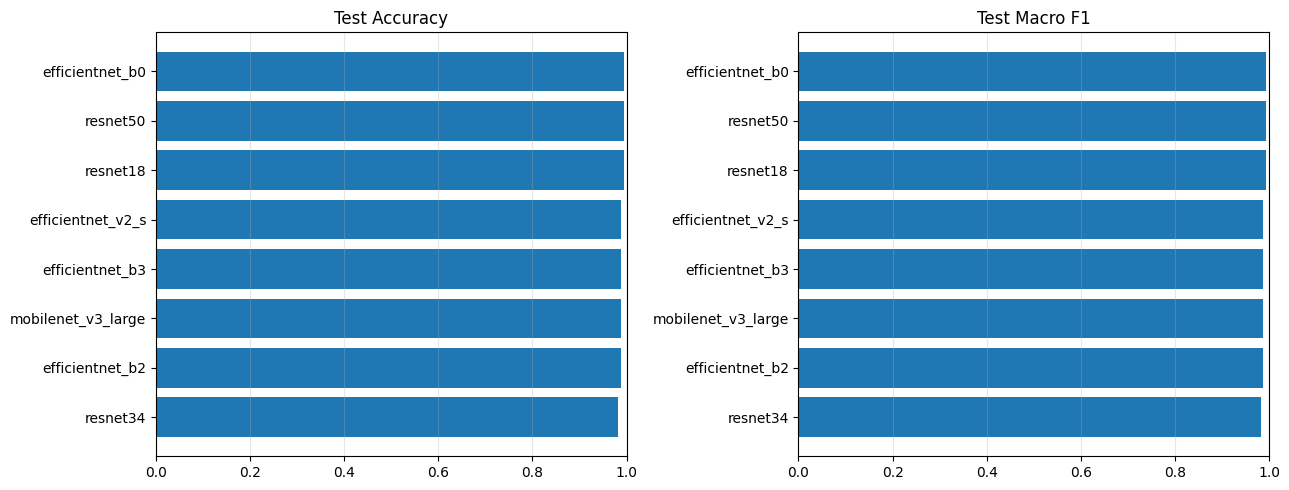

In [26]:
plot_df = results_df.sort_values("macro_f1", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(plot_df["model"], plot_df["accuracy"])
axes[0].set_title("Test Accuracy")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(plot_df["model"], plot_df["macro_f1"])
axes[1].set_title("Test Macro F1")
axes[1].set_xlim(0, 1)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 속도와 모델 크기 비교

실시간 웹캠 추론을 생각하면 정확도뿐 아니라 `ms_per_image`, 파일 크기, 파라미터 수도 같이 보는 것이 좋습니다.

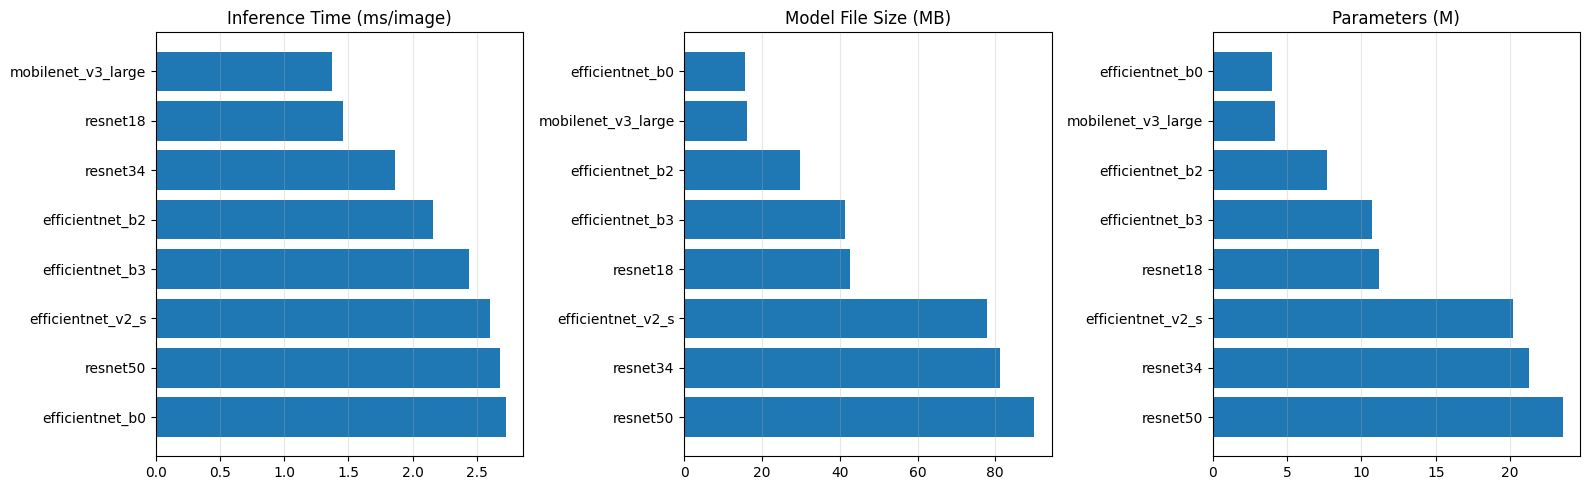

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

speed_df = results_df.sort_values("ms_per_image", ascending=False)
size_df = results_df.sort_values("file_size_mb", ascending=False)
param_df = results_df.sort_values("params_m", ascending=False)

axes[0].barh(speed_df["model"], speed_df["ms_per_image"])
axes[0].set_title("Inference Time (ms/image)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(size_df["model"], size_df["file_size_mb"])
axes[1].set_title("Model File Size (MB)")
axes[1].grid(axis="x", alpha=0.3)

axes[2].barh(param_df["model"], param_df["params_m"])
axes[2].set_title("Parameters (M)")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 가장 좋은 모델의 상세 리포트

기본 기준은 `macro_f1`이 가장 높은 모델입니다.

In [28]:
best_model_name = results_df.iloc[0]["model"]
print("가장 좋은 모델:", best_model_name)
print()

best_pred = predictions[best_model_name]
print(classification_report(
    best_pred["y_true"],
    best_pred["y_pred"],
    target_names=best_pred["class_names"],
    digits=4,
    zero_division=0,
))

가장 좋은 모델: efficientnet_b0

              precision    recall  f1-score   support

   Attentive     1.0000    1.0000    1.0000        53
      Drowsy     0.9831    1.0000    0.9915        58
 LookingAway     1.0000    0.9821    0.9910        56

    accuracy                         0.9940       167
   macro avg     0.9944    0.9940    0.9941       167
weighted avg     0.9941    0.9940    0.9940       167



## 12. 가장 좋은 모델의 Confusion Matrix

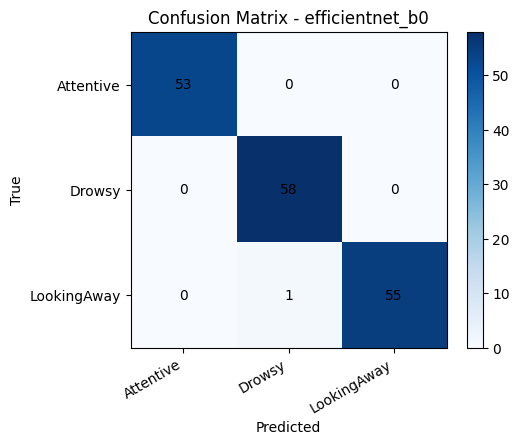

In [29]:
cm = confusion_matrices[best_model_name]
class_names = predictions[best_model_name]["class_names"]

plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=30, ha="right")
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 13. 원하는 모델의 상세 리포트 보기

아래 `selected_model` 값만 바꾸면 특정 모델의 report와 confusion matrix를 다시 볼 수 있습니다.

              precision    recall  f1-score   support

   Attentive     1.0000    1.0000    1.0000        53
      Drowsy     0.9831    1.0000    0.9915        58
 LookingAway     1.0000    0.9821    0.9910        56

    accuracy                         0.9940       167
   macro avg     0.9944    0.9940    0.9941       167
weighted avg     0.9941    0.9940    0.9940       167



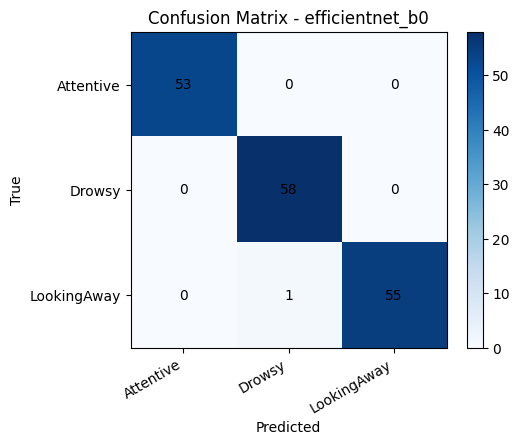

In [30]:
selected_model = best_model_name
# 예시:
# selected_model = "mobilenet_v3_large"
# selected_model = "efficientnet_b0"

if selected_model not in predictions:
    raise ValueError(f"평가된 모델 목록에 없습니다: {selected_model}")

selected_pred = predictions[selected_model]
selected_cm = confusion_matrices[selected_model]
selected_class_names = selected_pred["class_names"]

print(classification_report(
    selected_pred["y_true"],
    selected_pred["y_pred"],
    target_names=selected_class_names,
    digits=4,
    zero_division=0,
))

plt.figure(figsize=(5.5, 4.5))
plt.imshow(selected_cm, cmap="Blues")
plt.title(f"Confusion Matrix - {selected_model}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(selected_class_names)), selected_class_names, rotation=30, ha="right")
plt.yticks(range(len(selected_class_names)), selected_class_names)

for i in range(len(selected_class_names)):
    for j in range(len(selected_class_names)):
        plt.text(j, i, selected_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 14. 선택 기준 정리용 셀

아래 셀은 성능 기준으로 자동 추천 문장을 출력합니다. 실제 최종 선택은 정확도, 속도, 용량을 같이 보고 결정하면 됩니다.

In [31]:
best_f1 = results_df.sort_values("macro_f1", ascending=False).iloc[0]
fastest = results_df.sort_values("ms_per_image", ascending=True).iloc[0]
smallest = results_df.sort_values("file_size_mb", ascending=True).iloc[0]

print(f"성능 우선 추천: {best_f1['model']} | macro_f1={best_f1['macro_f1']:.4f}, acc={best_f1['accuracy']:.4f}")
print(f"속도 우선 추천: {fastest['model']} | {fastest['ms_per_image']:.3f} ms/image, macro_f1={fastest['macro_f1']:.4f}")
print(f"용량 우선 추천: {smallest['model']} | {smallest['file_size_mb']:.2f} MB, macro_f1={smallest['macro_f1']:.4f}")

성능 우선 추천: efficientnet_b0 | macro_f1=0.9941, acc=0.9940
속도 우선 추천: mobilenet_v3_large | 1.373 ms/image, macro_f1=0.9880
용량 우선 추천: efficientnet_b0 | 15.59 MB, macro_f1=0.9941


## 15. OpenCV 실시간 모델 감지 테스트

`realtime_model_name`에 확인하고 싶은 모델 이름을 넣고 실행하세요.

- 예시: `resnet18`, `resnet34`, `resnet50`, `mobilenet_v3_large`, `efficientnet_b0`, `efficientnet_b2`, `efficientnet_b3`, `efficientnet_v2_s`
- 저장 기능은 없습니다.
- OpenCV 창에서 현재 예측 상태와 클래스별 확률을 확인합니다.
- `q`를 누르면 Quit 후 종료합니다.

In [37]:
from collections import deque

import cv2
import mediapipe as mp
from PIL import Image


# 여기만 바꿔서 테스트하면 됩니다.
realtime_model_name = "resnet18"

camera_index = 0
frame_width = 960
frame_height = 720
window_name = f"Realtime Focus Detection - {realtime_model_name}"

face_model_path = Path("mp_model/face_landmarker.task")
face_padding_ratio = 0.25
probability_window_size = 10
confidence_threshold = 0.50
margin_threshold = 0.10


def load_model_for_realtime(model_name: str):
    model_path = model_dir / f"{model_name}_best.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"모델 파일을 찾지 못했습니다: {model_path}")

    checkpoint = load_checkpoint(model_path)
    checkpoint_model_name = infer_model_name(model_path, checkpoint)
    class_names = get_class_names(checkpoint)
    image_size = int(checkpoint.get("image_size", 224))

    model = create_model(checkpoint_model_name, len(class_names)).to(device)
    model.load_state_dict(get_model_state(checkpoint))
    model.eval()

    idx_to_class = {idx: name for idx, name in enumerate(class_names)}
    transform = make_eval_transform(image_size)
    return model, class_names, idx_to_class, transform, image_size, model_path


def load_realtime_face_landmarker():
    if not face_model_path.exists():
        raise FileNotFoundError(f"MediaPipe face model을 찾지 못했습니다: {face_model_path}")

    options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=str(face_model_path)),
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return mp.tasks.vision.FaceLandmarker.create_from_options(options)


def realtime_face_landmarks_to_bbox(face_landmarks, frame_width: int, frame_height: int):
    xs = [int(lm.x * frame_width) for lm in face_landmarks]
    ys = [int(lm.y * frame_height) for lm in face_landmarks]
    x1 = max(0, min(xs))
    y1 = max(0, min(ys))
    x2 = min(frame_width - 1, max(xs))
    y2 = min(frame_height - 1, max(ys))
    return x1, y1, x2, y2


def crop_face_for_realtime(frame_bgr, face_box, output_size: int, padding_ratio: float = face_padding_ratio):
    if face_box is None:
        return None

    height, width = frame_bgr.shape[:2]
    x1, y1, x2, y2 = face_box
    box_w = max(1, x2 - x1)
    box_h = max(1, y2 - y1)
    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    crop_x1 = max(0, x1 - pad_x)
    crop_y1 = max(0, y1 - pad_y)
    crop_x2 = min(width - 1, x2 + pad_x)
    crop_y2 = min(height - 1, y2 + pad_y)

    crop = frame_bgr[crop_y1:crop_y2 + 1, crop_x1:crop_x2 + 1]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_AREA)


def predict_realtime_crop(face_crop_bgr, model, transform):
    face_crop_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(face_crop_rgb)
    inputs = transform(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(inputs)
        return torch.softmax(outputs, dim=1).squeeze(0).cpu()


def choose_realtime_status(avg_probs: torch.Tensor, idx_to_class: dict[int, str]):
    top_probs, top_indices = torch.topk(avg_probs, k=min(2, len(avg_probs)))
    pred_idx = int(top_indices[0].item())
    pred_class = idx_to_class[pred_idx]
    pred_prob = float(top_probs[0].item())

    margin = pred_prob
    if len(top_probs) >= 2:
        margin = float(top_probs[0].item() - top_probs[1].item())

    if pred_prob < confidence_threshold or margin < margin_threshold:
        return "Uncertain", pred_prob
    return pred_class, pred_prob


def draw_realtime_overlay(frame_bgr, face_box, display_class, display_prob, display_probs, fps):
    if face_box is not None:
        x1, y1, x2, y2 = face_box
        cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (0, 255, 255), 2)

    lines = [
        f"Model: {realtime_model_name}",
        f"FPS: {fps:.1f}",
        f"Pred: {display_class} ({display_prob:.2f})",
    ]
    for class_name, prob in display_probs.items():
        lines.append(f"{class_name}: {prob:.2f}")
    lines.append("q: Quit")

    y = 32
    for line in lines:
        color = (0, 255, 0) if line.startswith("Pred:") else (255, 255, 255)
        cv2.putText(frame_bgr, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2, cv2.LINE_AA)
        y += 30
    return frame_bgr


model, class_names, idx_to_class, realtime_transform, image_size, loaded_model_path = load_model_for_realtime(realtime_model_name)
display_probs = {class_name: 0.0 for class_name in class_names}
probability_window = deque(maxlen=probability_window_size)
display_class = "Waiting"
display_prob = 0.0

print("loaded model:", loaded_model_path)
print("classes:", class_names)
print("image_size:", image_size)
print("q를 누르면 Quit 후 종료합니다.")

cv2.destroyAllWindows()

with load_realtime_face_landmarker() as face_landmarker:
    camera_capture = cv2.VideoCapture(camera_index)
    camera_capture.set(cv2.CAP_PROP_FRAME_WIDTH, frame_width)
    camera_capture.set(cv2.CAP_PROP_FRAME_HEIGHT, frame_height)

    if not camera_capture.isOpened():
        raise RuntimeError("Camera open failed. camera_index 또는 카메라 권한을 확인하세요.")

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    start_time = time.perf_counter()
    last_frame_time = time.perf_counter()

    try:
        while True:
            is_readable, frame_bgr = camera_capture.read()
            if not is_readable:
                print("Frame read failed.")
                break

            frame_bgr = cv2.flip(frame_bgr, 1)
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame_rgb))
            timestamp_ms = int((time.perf_counter() - start_time) * 1000)

            face_result = face_landmarker.detect_for_video(mp_image, timestamp_ms)
            face_landmarks_list = getattr(face_result, "face_landmarks", [])
            face_box = None

            if face_landmarks_list:
                face_box = realtime_face_landmarks_to_bbox(face_landmarks_list[0], frame_bgr.shape[1], frame_bgr.shape[0])
                face_crop_bgr = crop_face_for_realtime(frame_bgr, face_box, image_size)
                if face_crop_bgr is not None:
                    probs = predict_realtime_crop(face_crop_bgr, model, realtime_transform)
                    probability_window.append(probs)

                if probability_window:
                    avg_probs = torch.stack(list(probability_window)).mean(dim=0)
                    display_probs = {
                        idx_to_class[idx]: float(avg_probs[idx].item())
                        for idx in range(len(idx_to_class))
                    }
                    display_class, display_prob = choose_realtime_status(avg_probs, idx_to_class)
            else:
                probability_window.clear()
                display_class = "No Face"
                display_prob = 0.0
                display_probs = {class_name: 0.0 for class_name in class_names}

            current_time = time.perf_counter()
            fps = 1.0 / max(1e-6, current_time - last_frame_time)
            last_frame_time = current_time

            display_frame_bgr = draw_realtime_overlay(
                frame_bgr,
                face_box,
                display_class,
                display_prob,
                display_probs,
                fps,
            )
            cv2.imshow(window_name, display_frame_bgr)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                print("Quit")
                break
    finally:
        camera_capture.release()
        cv2.destroyAllWindows()

loaded model: models\resnet18_best.pt
classes: ['Attentive', 'Drowsy', 'LookingAway']
image_size: 224
q를 누르면 Quit 후 종료합니다.
Quit
